In [ ]:
In diesem Notebook wird die Research Question 1 Analysiert

1.	Wann ist die Nachfrage nach Yellow-Taxis in New York am höchsten?
Dabei werden die Fahrten nach Uhrzeit, Wochentag und Werktag/Wochenende gruppiert.


In [1]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
import matplotlib.pyplot as plt
import os

spark = SparkSession.builder \
    .appName("RQ1 Demand by Time") \
    .getOrCreate()

spark

26/05/25 14:22:07 WARN Utils: Your hostname, bdlc-021 resolves to a loopback address: 127.0.1.1; using 10.176.129.84 instead (on interface ens3)
26/05/25 14:22:07 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/25 14:22:07 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [2]:
# Hier kann zwischen Sample und vollständigem Datensatz gewechselt werden.
# USE_SAMPLE = True  -> Analyse mit kleinem Parquet-Sample
# USE_SAMPLE = False -> Analyse mit vollständigem Clean-Datensatz aus HDFS

USE_SAMPLE = False

RQ_NAME = "rq1_demand_by_time"

if USE_SAMPLE:
    DATA_PATH = "file:///home/cluster/BDLC/data_sample/yellow_taxi_clean_sample_84000_parquet"
    RESULT_PATH = f"/home/cluster/BDLC/results/prototype/{RQ_NAME}"
else:
    DATA_PATH = "/taxi/clean"
    RESULT_PATH = f"/home/cluster/BDLC/results/final/{RQ_NAME}"

os.makedirs(RESULT_PATH, exist_ok=True)

print("Using sample:", USE_SAMPLE)
print("Data path:", DATA_PATH)
print("Result path:", RESULT_PATH)

Using sample: False
Data path: /taxi/clean
Result path: /home/cluster/BDLC/results/final/rq1_demand_by_time


26/05/25 14:22:21 WARN GarbageCollectionMetrics: To enable non-built-in garbage collector(s) List(G1 Concurrent GC), users should configure it(them) to spark.eventLog.gcMetrics.youngGenerationGarbageCollectors or spark.eventLog.gcMetrics.oldGenerationGarbageCollectors


In [3]:
#Daten Laden und grösse Prüfen
df = spark.read.parquet(DATA_PATH)

df.printSchema()
print(df.count())

root
 |-- pickup_datetime: timestamp (nullable = true)
 |-- dropoff_datetime: timestamp (nullable = true)
 |-- passenger_count: double (nullable = true)
 |-- trip_distance_miles: double (nullable = true)
 |-- pickup_location_id: long (nullable = true)
 |-- dropoff_location_id: long (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- pickup_year: integer (nullable = true)
 |-- pickup_month: integer (nullable = true)
 |-- pickup_hour: integer (nullable = true)
 |-- pickup_weekday: integer (nullable = true)
 |-- trip_duration_minutes: double (nullable = true)
 |-- trip_distance_km: double (nullable = true)
 |-- avg_speed_kmh: double (nullable = true)
 |-- tip_percentage: double (nullable = true)
 |-- file_year: integer (nullable = true)
 |-- file_month: integer (nullable = true)



[Stage 1:=====================================================> (161 + 4) / 165]

620366041


In [4]:
# Prüfen, welche Jahre und Monate im Datensatz enthalten sind.

df.select("file_year", "file_month") \
    .distinct() \
    .orderBy("file_year", "file_month") \
    .show(100)

+---------+----------+
|file_year|file_month|
+---------+----------+
|     2015|         1|
|     2015|         2|
|     2015|         3|
|     2015|         4|
|     2015|         5|
|     2015|         6|
|     2015|         7|
|     2015|         8|
|     2015|         9|
|     2015|        10|
|     2015|        11|
|     2015|        12|
|     2016|         1|
|     2016|         2|
|     2016|         3|
|     2016|         4|
|     2016|         5|
|     2016|         6|
|     2016|         7|
|     2016|         8|
|     2016|         9|
|     2016|        10|
|     2016|        11|
|     2016|        12|
|     2017|         1|
|     2017|         2|
|     2017|         3|
|     2017|         4|
|     2017|         5|
|     2017|         6|
|     2017|         7|
|     2017|         8|
|     2017|         9|
|     2017|        10|
|     2017|        11|
|     2017|        12|
|     2018|         1|
|     2018|         2|
|     2018|         3|
|     2018|         4|
|     2018|

In [ ]:
Analyse 1: Fahrten pro Jahr

In [5]:
# Anzahl Fahrten pro Jahr berechnen.
# Dadurch sieht man, wie sich die Nachfrage über die Jahre verändert.

trips_per_year = df.groupBy("file_year") \
    .agg(F.count("*").alias("number_of_trips")) \
    .orderBy("file_year")

trips_per_year.show()

[Stage 7:======================================================>(163 + 2) / 165]

+---------+---------------+
|file_year|number_of_trips|
+---------+---------------+
|     2015|      144808589|
|     2016|      129978027|
|     2017|      112251722|
|     2018|      100801269|
|     2019|       81464315|
|     2020|       22889141|
|     2021|       28172978|
+---------+---------------+



In [6]:
# Aggregierte Tabelle als CSV speichern.
# Diese Tabelle kann später für die Dokumentation oder Plausibilitätskontrolle verwendet werden.

trips_per_year_pd = trips_per_year.toPandas()

trips_per_year_pd.to_csv(
    f"{RESULT_PATH}/trips_per_year.csv",
    index=False
)

trips_per_year_pd

,file_year,number_of_trips
0,2015,144808589
1,2016,129978027
2,2017,112251722
3,2018,100801269
4,2019,81464315
5,2020,22889141
6,2021,28172978


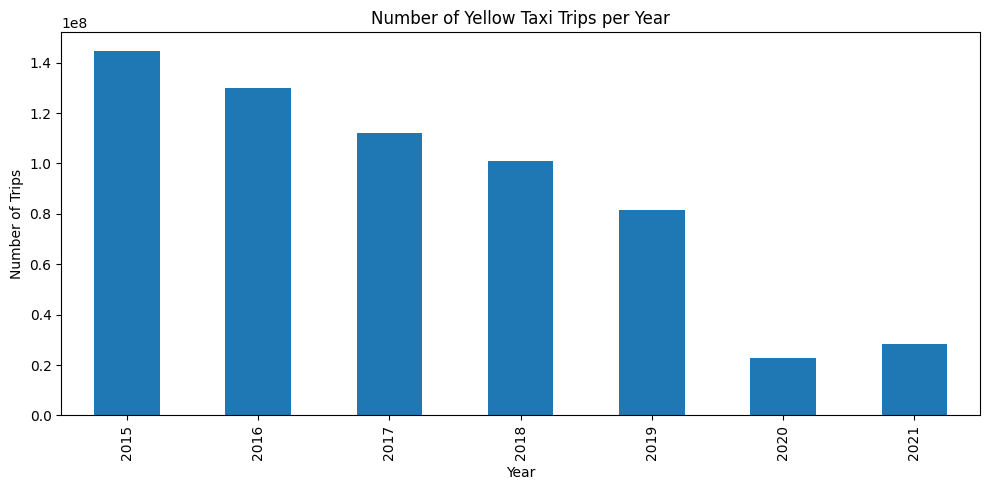

In [7]:
# Balkendiagramm: Anzahl Fahrten pro Jahr.
# Erwartung: 2020 und 2021 sind deutlich tiefer als 2015-2019.

ax = trips_per_year_pd.plot(
    x="file_year",
    y="number_of_trips",
    kind="bar",
    figsize=(10, 5),
    legend=False,
    title="Number of Yellow Taxi Trips per Year"
)

ax.set_xlabel("Year")
ax.set_ylabel("Number of Trips")

plt.tight_layout()
plt.savefig(f"{RESULT_PATH}/trips_per_year.png", dpi=150)
plt.show()

In [ ]:
Analyse 2 Fahrten pro Monat

In [8]:
# Anzahl Fahrten pro Jahr und Monat berechnen.
# Damit werden saisonale Muster und Einbrüche über die Zeit sichtbar.

trips_per_month = df.groupBy("file_year", "file_month") \
    .agg(F.count("*").alias("number_of_trips")) \
    .orderBy("file_year", "file_month")

trips_per_month.show(100)

[Stage 18:=====================================================>(162 + 3) / 165]

+---------+----------+---------------+
|file_year|file_month|number_of_trips|
+---------+----------+---------------+
|     2015|         1|       12638846|
|     2015|         2|       12340993|
|     2015|         3|       13225708|
|     2015|         4|       12957347|
|     2015|         5|       13048522|
|     2015|         6|       12224181|
|     2015|         7|       11465864|
|     2015|         8|       11033673|
|     2015|         9|       11119358|
|     2015|        10|       12200591|
|     2015|        11|       11201461|
|     2015|        12|       11352045|
|     2016|         1|       10812865|
|     2016|         2|       11283121|
|     2016|         3|       12101305|
|     2016|         4|       11821761|
|     2016|         5|       11730663|
|     2016|         6|       11033993|
|     2016|         7|       10200809|
|     2016|         8|        9853029|
|     2016|         9|       10023762|
|     2016|        10|       10757304|
|     2016|        11|   

In [9]:
# Tabelle in Pandas umwandeln und eine lesbare year_month-Spalte erstellen.

trips_per_month_pd = trips_per_month.toPandas()

trips_per_month_pd["year_month"] = (
    trips_per_month_pd["file_year"].astype(str)
    + "-"
    + trips_per_month_pd["file_month"].astype(str).str.zfill(2)
)

trips_per_month_pd.to_csv(
    f"{RESULT_PATH}/trips_per_month.csv",
    index=False
)

trips_per_month_pd.head()

,file_year,file_month,number_of_trips,year_month
0,2015,1,12638846,2015-01
1,2015,2,12340993,2015-02
2,2015,3,13225708,2015-03
3,2015,4,12957347,2015-04
4,2015,5,13048522,2015-05


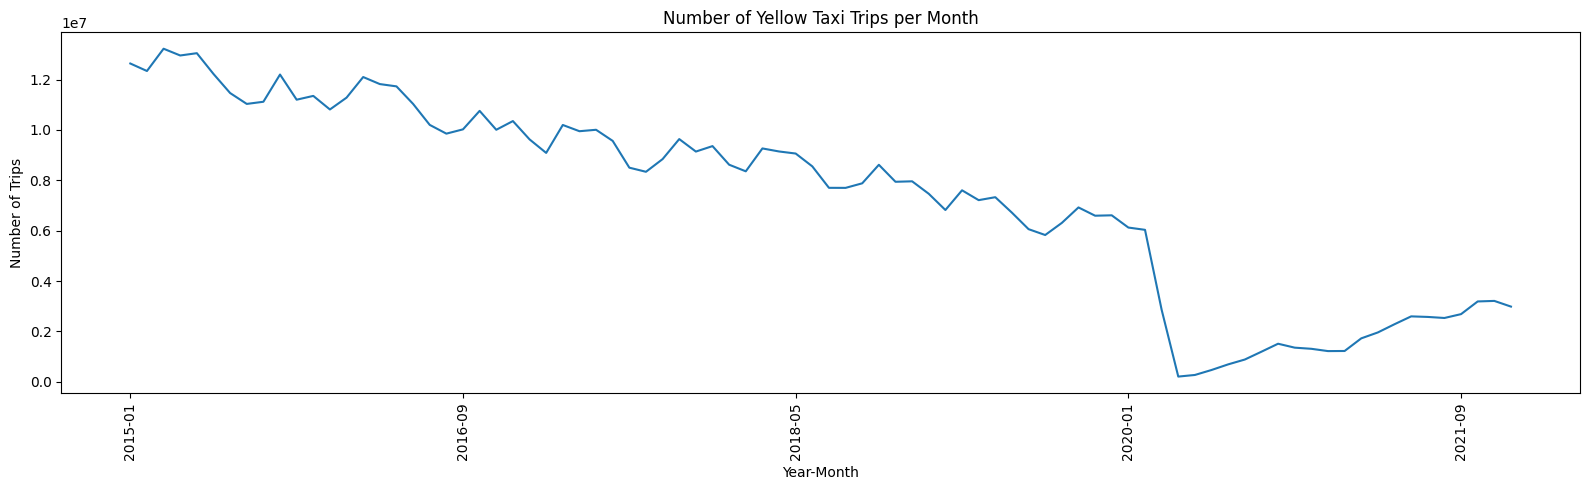

In [10]:
# Liniendiagramm: Anzahl Fahrten pro Monat.
# Dadurch sieht man die zeitliche Entwicklung der Nachfrage.

ax = trips_per_month_pd.plot(
    x="year_month",
    y="number_of_trips",
    kind="line",
    figsize=(16, 5),
    legend=False,
    title="Number of Yellow Taxi Trips per Month"
)

ax.set_xlabel("Year-Month")
ax.set_ylabel("Number of Trips")

plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig(f"{RESULT_PATH}/trips_per_month.png", dpi=150)
plt.show()

In [ ]:
Analyse 3: Fahrten pro Stunde

In [11]:
# Anzahl Fahrten pro Stunde berechnen.
# pickup_hour wurde bereits im Preprocessing aus dem Pickup-Zeitpunkt erstellt.

trips_by_hour = df.groupBy("pickup_hour") \
    .agg(F.count("*").alias("number_of_trips")) \
    .orderBy("pickup_hour")

trips_by_hour.show(24)

[Stage 29:=================================================>   (155 + 10) / 165]

+-----------+---------------+
|pickup_hour|number_of_trips|
+-----------+---------------+
|          0|       20752417|
|          1|       14880578|
|          2|       10652604|
|          3|        7773016|
|          4|        5874652|
|          5|        6047169|
|          6|       13558651|
|          7|       22785757|
|          8|       28131583|
|          9|       28793776|
|         10|       28750743|
|         11|       30058353|
|         12|       31792301|
|         13|       31973440|
|         14|       33432155|
|         15|       32797465|
|         16|       29964396|
|         17|       34351845|
|         18|       39077775|
|         19|       38329486|
|         20|       35229676|
|         21|       34764411|
|         22|       32968225|
|         23|       27625567|
+-----------+---------------+



In [12]:
# Aggregierte Stunden-Tabelle speichern.

trips_by_hour_pd = trips_by_hour.toPandas()

trips_by_hour_pd.to_csv(
    f"{RESULT_PATH}/trips_by_hour.csv",
    index=False
)

trips_by_hour_pd

,pickup_hour,number_of_trips
0,0,20752417
1,1,14880578
2,2,10652604
3,3,7773016
4,4,5874652
5,5,6047169
6,6,13558651
7,7,22785757
8,8,28131583
9,9,28793776


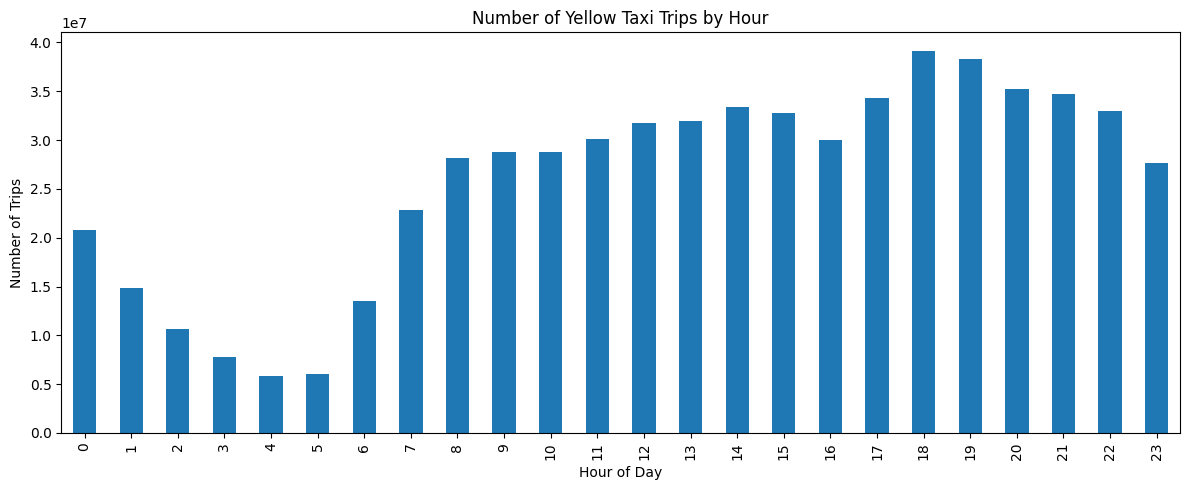

In [13]:
# Balkendiagramm: Anzahl Fahrten pro Stunde.
# Damit wird sichtbar, zu welcher Uhrzeit die Nachfrage am höchsten ist.

ax = trips_by_hour_pd.plot(
    x="pickup_hour",
    y="number_of_trips",
    kind="bar",
    figsize=(12, 5),
    legend=False,
    title="Number of Yellow Taxi Trips by Hour"
)

ax.set_xlabel("Hour of Day")
ax.set_ylabel("Number of Trips")

plt.tight_layout()
plt.savefig(f"{RESULT_PATH}/trips_by_hour.png", dpi=150)
plt.show()

In [14]:
# Die Stunde mit der höchsten Anzahl Fahrten bestimmen.

max_hour = trips_by_hour.orderBy(F.desc("number_of_trips")).limit(1)

max_hour.show()

[Stage 40:===============================================>     (147 + 13) / 165]

+-----------+---------------+
|pickup_hour|number_of_trips|
+-----------+---------------+
|         18|       39077775|
+-----------+---------------+



In [ ]:
Analyse 4: Fahrten pro Wochentag

In [15]:
# Spark dayofweek:
# 1 = Sunday
# 2 = Monday
# 3 = Tuesday
# 4 = Wednesday
# 5 = Thursday
# 6 = Friday
# 7 = Saturday
#
# Für die Darstellung soll die Woche mit Monday beginnen.
# Deshalb erstellen wir zusätzlich weekday_order:
# Monday = 1, ..., Sunday = 7

df_weekday = df.withColumn(
    "weekday_name",
    F.when(F.col("pickup_weekday") == 1, "Sunday")
     .when(F.col("pickup_weekday") == 2, "Monday")
     .when(F.col("pickup_weekday") == 3, "Tuesday")
     .when(F.col("pickup_weekday") == 4, "Wednesday")
     .when(F.col("pickup_weekday") == 5, "Thursday")
     .when(F.col("pickup_weekday") == 6, "Friday")
     .when(F.col("pickup_weekday") == 7, "Saturday")
).withColumn(
    "weekday_order",
    F.when(F.col("pickup_weekday") == 2, 1)  # Monday
     .when(F.col("pickup_weekday") == 3, 2)  # Tuesday
     .when(F.col("pickup_weekday") == 4, 3)  # Wednesday
     .when(F.col("pickup_weekday") == 5, 4)  # Thursday
     .when(F.col("pickup_weekday") == 6, 5)  # Friday
     .when(F.col("pickup_weekday") == 7, 6)  # Saturday
     .when(F.col("pickup_weekday") == 1, 7)  # Sunday
)

In [16]:
# Anzahl Fahrten pro Wochentag berechnen.
# Sortiert wird mit weekday_order, damit Monday zuerst kommt.

trips_by_weekday = df_weekday.groupBy(
    "weekday_order",
    "weekday_name"
).agg(
    F.count("*").alias("number_of_trips")
).orderBy("weekday_order")

trips_by_weekday.show()

[Stage 43:===================================================>  (157 + 8) / 165]

+-------------+------------+---------------+
|weekday_order|weekday_name|number_of_trips|
+-------------+------------+---------------+
|            1|      Monday|       80193869|
|            2|     Tuesday|       87547004|
|            3|   Wednesday|       91168395|
|            4|    Thursday|       93890187|
|            5|      Friday|       95007877|
|            6|    Saturday|       92425115|
|            7|      Sunday|       80133594|
+-------------+------------+---------------+



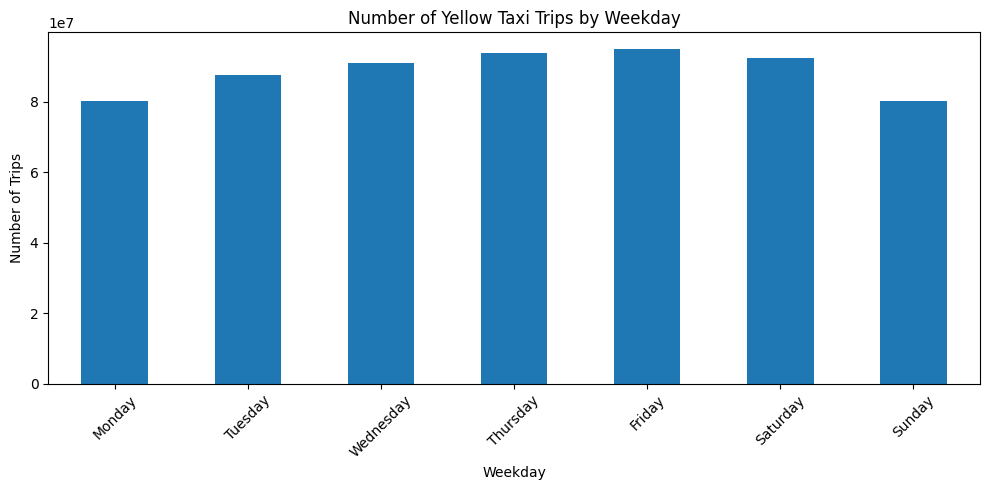

In [17]:
# Tabelle speichern und als Balkendiagramm anzeigen.

trips_by_weekday_pd = trips_by_weekday.toPandas()

trips_by_weekday_pd.to_csv(
    f"{RESULT_PATH}/trips_by_weekday.csv",
    index=False
)

ax = trips_by_weekday_pd.plot(
    x="weekday_name",
    y="number_of_trips",
    kind="bar",
    figsize=(10, 5),
    legend=False,
    title="Number of Yellow Taxi Trips by Weekday"
)

ax.set_xlabel("Weekday")
ax.set_ylabel("Number of Trips")

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f"{RESULT_PATH}/trips_by_weekday.png", dpi=150)
plt.show()

In [ ]:
Analyse 5: Werktag vs. Wochenende

In [18]:
# Neue Kategorie erstellen:
# Weekend = Samstag oder Sonntag
# Weekday = Montag bis Freitag

df_day_type = df_weekday.withColumn(
    "day_type",
    F.when(F.col("pickup_weekday").isin(1, 7), "Weekend")
     .otherwise("Weekday")
)

In [19]:
# Absolute Anzahl Fahrten nach Weekday/Weekend berechnen.
# Wichtig: Dieser Vergleich ist nicht ganz fair, weil es mehr Werktage als Wochenendtage gibt.

trips_by_day_type = df_day_type.groupBy("day_type") \
    .agg(F.count("*").alias("number_of_trips")) \
    .orderBy("day_type")

trips_by_day_type.show()

[Stage 54:====================================================> (159 + 6) / 165]

+--------+---------------+
|day_type|number_of_trips|
+--------+---------------+
| Weekday|      447807332|
| Weekend|      172558709|
+--------+---------------+



In [20]:
# Fairerer Vergleich:
# Nicht nur absolute Anzahl Fahrten, sondern durchschnittliche Fahrten pro Kalendertag.
# Dafür wird zuerst das Pickup-Datum erzeugt.

df_day_type_date = df_day_type.withColumn(
    "pickup_date",
    F.to_date("pickup_datetime")
)

trips_per_calendar_day = df_day_type_date.groupBy("pickup_date", "day_type") \
    .agg(F.count("*").alias("trips_per_day"))

avg_trips_by_day_type = trips_per_calendar_day.groupBy("day_type") \
    .agg(
        F.round(F.avg("trips_per_day"), 2).alias("avg_trips_per_day"),
        F.count("*").alias("number_of_days")
    ) \
    .orderBy("day_type")

avg_trips_by_day_type.show()

[Stage 57:====================================================> (159 + 6) / 165]

+--------+-----------------+--------------+
|day_type|avg_trips_per_day|number_of_days|
+--------+-----------------+--------------+
| Weekday|        245105.27|          1827|
| Weekend|        236381.79|           730|
+--------+-----------------+--------------+



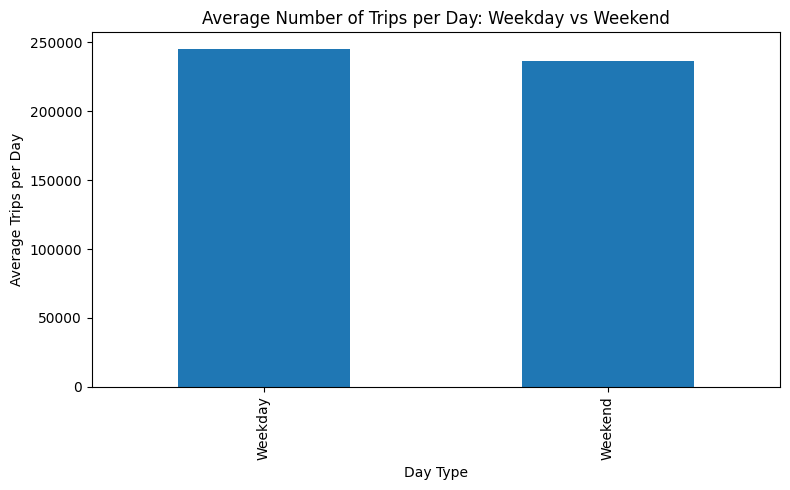

In [21]:
# Durchschnittliche Fahrten pro Tag speichern und visualisieren.

avg_trips_by_day_type_pd = avg_trips_by_day_type.toPandas()

avg_trips_by_day_type_pd.to_csv(
    f"{RESULT_PATH}/avg_trips_by_day_type.csv",
    index=False
)

ax = avg_trips_by_day_type_pd.plot(
    x="day_type",
    y="avg_trips_per_day",
    kind="bar",
    figsize=(8, 5),
    legend=False,
    title="Average Number of Trips per Day: Weekday vs Weekend"
)

ax.set_xlabel("Day Type")
ax.set_ylabel("Average Trips per Day")

plt.tight_layout()
plt.savefig(f"{RESULT_PATH}/avg_trips_by_day_type.png", dpi=150)
plt.show()

In [ ]:
Analyse 6: Heatmap Wochentag × Uhrzeit

In [22]:
# Anzahl Fahrten nach Wochentag und Stunde berechnen.
# Diese Kombination zeigt besonders gut, wann die Nachfrage am höchsten ist.
# Sortiert wird mit weekday_order, damit Monday zuerst kommt.

trips_weekday_hour = df_weekday.groupBy(
    "weekday_order",
    "weekday_name",
    "pickup_hour"
).agg(
    F.count("*").alias("number_of_trips")
).orderBy(
    "weekday_order",
    "pickup_hour"
)

trips_weekday_hour.show(200)

[Stage 76:================================================>    (151 + 12) / 165]

+-------------+------------+-----------+---------------+
|weekday_order|weekday_name|pickup_hour|number_of_trips|
+-------------+------------+-----------+---------------+
|            1|      Monday|          0|        1648448|
|            1|      Monday|          1|         991107|
|            1|      Monday|          2|         643898|
|            1|      Monday|          3|         456711|
|            1|      Monday|          4|         517434|
|            1|      Monday|          5|         882290|
|            1|      Monday|          6|        2197667|
|            1|      Monday|          7|        3615445|
|            1|      Monday|          8|        4340915|
|            1|      Monday|          9|        4165175|
|            1|      Monday|         10|        3858703|
|            1|      Monday|         11|        3899930|
|            1|      Monday|         12|        4104133|
|            1|      Monday|         13|        4157336|
|            1|      Monday|   

In [23]:
# Spark-Ergebnis in Pandas umwandeln und als CSV speichern.

trips_weekday_hour_pd = trips_weekday_hour.toPandas()

trips_weekday_hour_pd.to_csv(
    f"{RESULT_PATH}/trips_weekday_hour.csv",
    index=False
)

trips_weekday_hour_pd.head()

,weekday_order,weekday_name,pickup_hour,number_of_trips
0,1,Monday,0,1648448
1,1,Monday,1,991107
2,1,Monday,2,643898
3,1,Monday,3,456711
4,1,Monday,4,517434


In [24]:
# Pivot-Tabelle erstellen:
# Zeilen = Wochentage
# Spalten = Stunden
# Werte = Anzahl Fahrten
#
# Die Reihenfolge wird manuell auf Monday bis Sunday gesetzt.

heatmap_data = trips_weekday_hour_pd.pivot(
    index="weekday_name",
    columns="pickup_hour",
    values="number_of_trips"
)

weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

heatmap_data = heatmap_data.reindex(weekday_order)

heatmap_data

pickup_hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
weekday_name,,,,,,,,,,,,,,,,,,,,,
Monday,1648448,991107,643898,456711,517434,882290,2197667,3615445,4340915,4165175,...,4492488,4543659,4228863,4862930,5499350,5160567,4727131,4529074,3903322,2767293
Tuesday,1751026,993516,606325,404875,438089,862700,2347948,4079167,4875493,4617425,...,4791058,4711882,4224144,4986739,5843285,5637716,5365201,5360226,4766247,3462526
Wednesday,2161068,1238609,760935,504632,501101,882072,2376575,4185424,5009597,4727294,...,4855979,4730434,4206556,5003913,5876346,5860545,5578102,5601829,5144352,3933572
Thursday,2530028,1484364,922792,612530,574798,918084,2409052,4215627,5002339,4729089,...,4965081,4781896,4199733,4998835,5899925,5934643,5725088,5778518,5455787,4615808
Friday,3356988,2156335,1387062,918128,769472,970807,2304808,3923513,4734127,4546726,...,4939129,4728670,4238575,5054913,5911067,6031573,5344306,5235150,5431813,5219697
Saturday,4622193,3857344,3107521,2263030,1447030,761807,1051438,1555218,2349590,3321724,...,4790200,4846082,4545961,4961692,5469900,5568404,4744512,4699855,5090741,5144394
Sunday,4682666,4159303,3224071,2613110,1626728,769409,871163,1211363,1819522,2686343,...,4598220,4454842,4320564,4482823,4577902,4136038,3745336,3559759,3175963,2482277


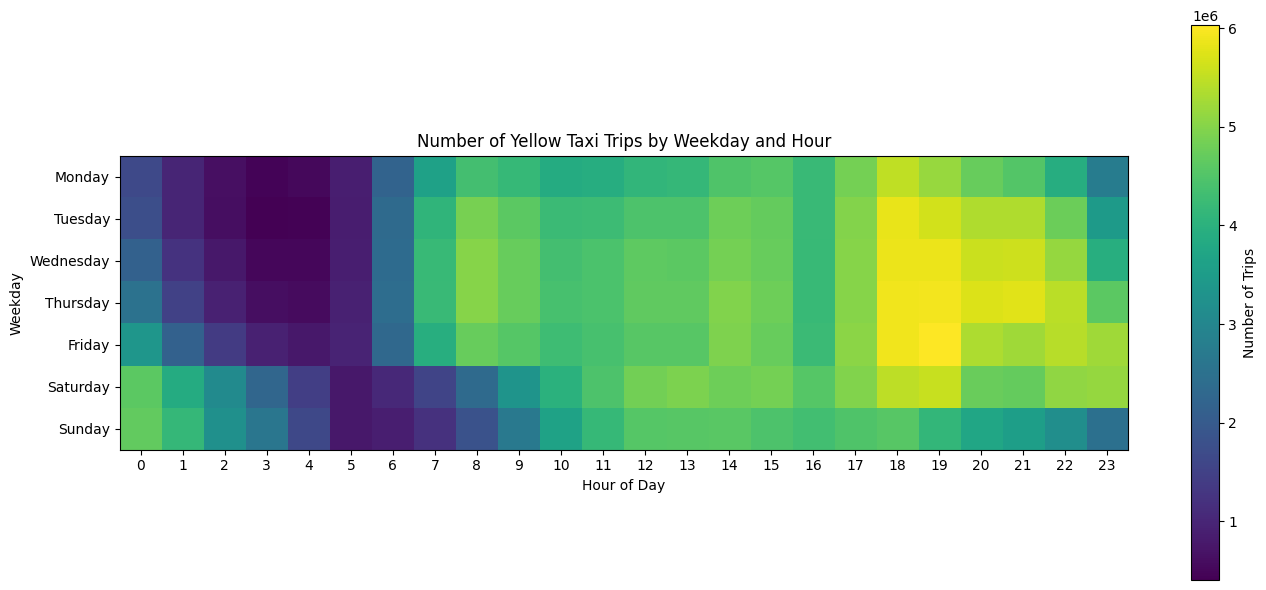

In [25]:
# Heatmap mit matplotlib erstellen.
# Je dunkler/höher der Wert, desto mehr Fahrten gibt es in dieser Kombination aus Wochentag und Stunde.

fig, ax = plt.subplots(figsize=(14, 6))

image = ax.imshow(heatmap_data)

ax.set_xticks(range(len(heatmap_data.columns)))
ax.set_xticklabels(heatmap_data.columns)

ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index)

ax.set_xlabel("Hour of Day")
ax.set_ylabel("Weekday")
ax.set_title("Number of Yellow Taxi Trips by Weekday and Hour")

plt.colorbar(image, ax=ax, label="Number of Trips")

plt.tight_layout()
plt.savefig(f"{RESULT_PATH}/heatmap_weekday_hour.png", dpi=150)
plt.show()

In [ ]:
Analyse 7: Weekday vs Weekend Heatmap
Neben der allgemeinen Verteilung nach Wochentag wird zusätzlich untersucht, ob sich die Nachfragekurve zwischen Werktagen und Wochenenden unterscheidet.
Da es mehr Werktage als Wochenendtage gibt, wird nicht die absolute Anzahl Fahrten verglichen. 
Stattdessen wird die durchschnittliche Anzahl Fahrten pro Tag und Stunde berechnet.

In [26]:
# Für einen fairen Vergleich zwischen Weekday und Weekend wird nicht die absolute Anzahl Fahrten verwendet.
# Stattdessen berechnen wir die durchschnittliche Anzahl Fahrten pro Tag und Stunde.
# So wird berücksichtigt, dass es mehr Werktage als Wochenendtage gibt.

df_day_type_hour = df_day_type.withColumn(
    "pickup_date",
    F.to_date("pickup_datetime")
)

trips_day_type_hour_daily = df_day_type_hour.groupBy(
    "pickup_date",
    "day_type",
    "pickup_hour"
).agg(
    F.count("*").alias("trips_per_day_hour")
)

avg_trips_day_type_hour = trips_day_type_hour_daily.groupBy(
    "day_type",
    "pickup_hour"
).agg(
    F.round(F.avg("trips_per_day_hour"), 2).alias("avg_trips_per_day_hour")
).orderBy(
    "day_type",
    "pickup_hour"
)

avg_trips_day_type_hour.show(100)

[Stage 87:=====================================================>(163 + 2) / 165]

+--------+-----------+----------------------+
|day_type|pickup_hour|avg_trips_per_day_hour|
+--------+-----------+----------------------+
| Weekday|          0|               6265.77|
| Weekday|          1|               3756.94|
| Weekday|          2|               2365.09|
| Weekday|          3|               1585.59|
| Weekday|          4|               1533.06|
| Weekday|          5|               2471.79|
| Weekday|          6|               6368.94|
| Weekday|          7|               10957.4|
| Weekday|          8|              13115.75|
| Weekday|          9|              12471.65|
| Weekday|         10|              11562.32|
| Weekday|         11|              11723.02|
| Weekday|         12|              12264.34|
| Weekday|         13|              12294.97|
| Weekday|         14|              13160.23|
| Weekday|         15|              12860.72|
| Weekday|         16|              11547.82|
| Weekday|         17|              13632.91|
| Weekday|         18|            

In [27]:
# Ergebnis als CSV speichern, damit die Zahlen später nachvollziehbar bleiben.

avg_trips_day_type_hour_pd = avg_trips_day_type_hour.toPandas()

avg_trips_day_type_hour_pd.to_csv(
    f"{RESULT_PATH}/avg_trips_day_type_hour.csv",
    index=False
)

avg_trips_day_type_hour_pd.head()

,day_type,pickup_hour,avg_trips_per_day_hour
0,Weekday,0,6265.77
1,Weekday,1,3756.94
2,Weekday,2,2365.09
3,Weekday,3,1585.59
4,Weekday,4,1533.06


In [28]:
# Pivot-Tabelle erstellen:
# Zeilen = Weekday / Weekend
# Spalten = Stunden
# Werte = durchschnittliche Fahrten pro Tag und Stunde

heatmap_day_type = avg_trips_day_type_hour_pd.pivot(
    index="day_type",
    columns="pickup_hour",
    values="avg_trips_per_day_hour"
)

heatmap_day_type = heatmap_day_type.reindex(["Weekday", "Weekend"])

heatmap_day_type

pickup_hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
day_type,,,,,,,,,,,,,,,,,,,,,
Weekday,6265.77,3756.94,2365.09,1585.59,1533.06,2471.79,6368.94,10957.40,13115.75,12471.65,...,13160.23,12860.72,11547.82,13632.91,15889.42,15667.79,14635.92,14507.28,13520.26,10946.30
Weekend,12746.38,10981.71,8793.88,6679.64,4210.63,2097.56,2633.70,3789.84,5711.11,8230.23,...,12860.85,12740.99,12145.92,12937.69,13764.11,13293.76,11629.93,11314.54,11324.25,10447.49


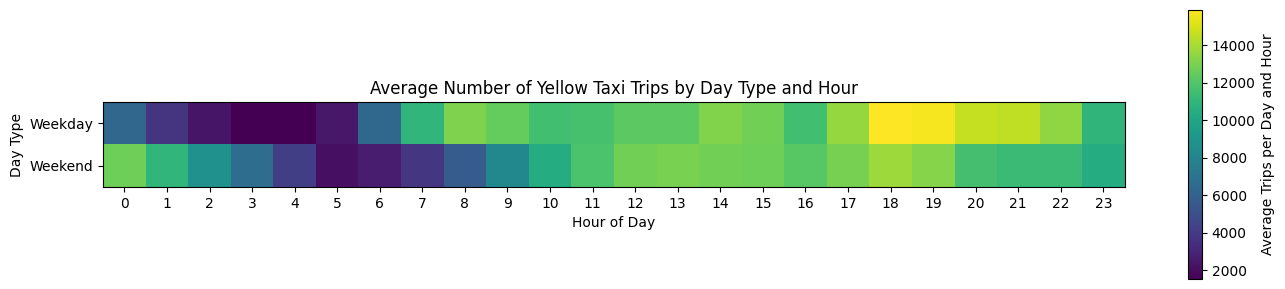

In [29]:
# Heatmap für Weekday vs Weekend nach Uhrzeit.
# Dadurch sieht man, ob sich die Nachfragekurve am Wochenende anders verteilt als unter der Woche.

fig, ax = plt.subplots(figsize=(14, 3))

image = ax.imshow(heatmap_day_type)

ax.set_xticks(range(len(heatmap_day_type.columns)))
ax.set_xticklabels(heatmap_day_type.columns)

ax.set_yticks(range(len(heatmap_day_type.index)))
ax.set_yticklabels(heatmap_day_type.index)

ax.set_xlabel("Hour of Day")
ax.set_ylabel("Day Type")
ax.set_title("Average Number of Yellow Taxi Trips by Day Type and Hour")

plt.colorbar(image, ax=ax, label="Average Trips per Day and Hour")

plt.tight_layout()
plt.savefig(f"{RESULT_PATH}/heatmap_day_type_hour.png", dpi=150)
plt.show()

In [ ]:
Analyse 8: Vor-Corona vs. Corona-Zeitraum

In [30]:
# 2015-2019 = pre_covid
# 2020-2021 = covid_period
# Damit kann geprüft werden, ob sich die Nachfrageverteilung über den Tag verändert hat.

df_period = df.withColumn(
    "period",
    F.when(F.col("file_year").between(2015, 2019), "2015-2019")
     .when(F.col("file_year").between(2020, 2021), "2020-2021")
)

In [31]:
# Anzahl Fahrten pro Stunde je Periode berechnen.

trips_by_hour_period = df_period.groupBy("period", "pickup_hour") \
    .agg(F.count("*").alias("number_of_trips")) \
    .orderBy("period", "pickup_hour")

trips_by_hour_period.show(100)

[Stage 106:====================================================>(163 + 2) / 165]

+---------+-----------+---------------+
|   period|pickup_hour|number_of_trips|
+---------+-----------+---------------+
|2015-2019|          0|       19622784|
|2015-2019|          1|       14139647|
|2015-2019|          2|       10166306|
|2015-2019|          3|        7449067|
|2015-2019|          4|        5645447|
|2015-2019|          5|        5732181|
|2015-2019|          6|       12691439|
|2015-2019|          7|       21176791|
|2015-2019|          8|       25930743|
|2015-2019|          9|       26406999|
|2015-2019|         10|       26170602|
|2015-2019|         11|       27268126|
|2015-2019|         12|       28744908|
|2015-2019|         13|       28842948|
|2015-2019|         14|       30059239|
|2015-2019|         15|       29360209|
|2015-2019|         16|       26670497|
|2015-2019|         17|       30825710|
|2015-2019|         18|       35447690|
|2015-2019|         19|       35154194|
|2015-2019|         20|       32625007|
|2015-2019|         21|       32372564|


In [32]:
# Für einen faireren Vergleich wird der Anteil pro Stunde innerhalb der Periode berechnet.
# Sonst würden 2015-2019 wegen mehr Records automatisch dominieren.

period_totals = trips_by_hour_period.groupBy("period") \
    .agg(F.sum("number_of_trips").alias("total_trips_period"))

trips_by_hour_period_pct = trips_by_hour_period.join(
    period_totals,
    on="period",
    how="inner"
).withColumn(
    "percentage_of_period",
    F.round(F.col("number_of_trips") / F.col("total_trips_period") * 100, 4)
).orderBy(
    "period",
    "pickup_hour"
)

trips_by_hour_period_pct.show(100)

+---------+-----------+---------------+------------------+--------------------+
|   period|pickup_hour|number_of_trips|total_trips_period|percentage_of_period|
+---------+-----------+---------------+------------------+--------------------+
|2015-2019|          0|       19622784|         569303922|              3.4468|
|2015-2019|          1|       14139647|         569303922|              2.4837|
|2015-2019|          2|       10166306|         569303922|              1.7857|
|2015-2019|          3|        7449067|         569303922|              1.3085|
|2015-2019|          4|        5645447|         569303922|              0.9916|
|2015-2019|          5|        5732181|         569303922|              1.0069|
|2015-2019|          6|       12691439|         569303922|              2.2293|
|2015-2019|          7|       21176791|         569303922|              3.7198|
|2015-2019|          8|       25930743|         569303922|              4.5548|
|2015-2019|          9|       26406999| 

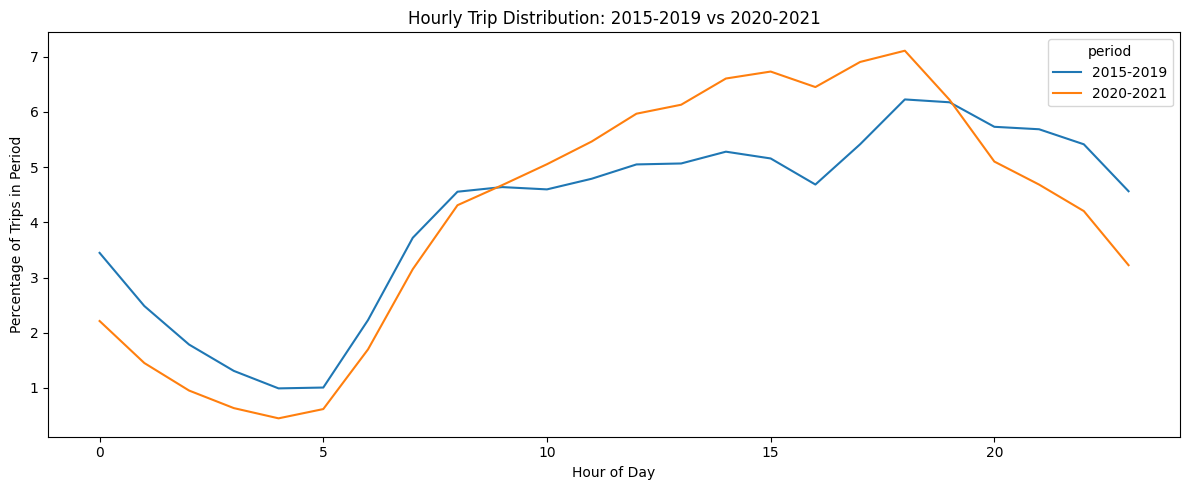

In [33]:
# Tabelle speichern und als Liniendiagramm visualisieren.

trips_by_hour_period_pd = trips_by_hour_period_pct.toPandas()

trips_by_hour_period_pd.to_csv(
    f"{RESULT_PATH}/trips_by_hour_period.csv",
    index=False
)

period_pivot = trips_by_hour_period_pd.pivot(
    index="pickup_hour",
    columns="period",
    values="percentage_of_period"
)

ax = period_pivot.plot(
    kind="line",
    figsize=(12, 5),
    title="Hourly Trip Distribution: 2015-2019 vs 2020-2021"
)

ax.set_xlabel("Hour of Day")
ax.set_ylabel("Percentage of Trips in Period")

plt.tight_layout()
plt.savefig(f"{RESULT_PATH}/trips_by_hour_period.png", dpi=150)
plt.show()

In [34]:
spark.stop()